<a href="https://colab.research.google.com/github/sachin-582/data_sales_analysis-/blob/main/DA_project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python Libreary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data Set

In [4]:
df = pd.read_excel("/content/Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.dropna(inplace=True)

In [6]:
df = df[df['Quantity'] > 0]

In [7]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [8]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
count,397924.000000,397924,397924.000000,397924.000000,397924.000000
mean,13.021823,2011-07-10 23:43:36.912475648,3.116174,15294.315171,22.394749
min,1.000000,2010-12-01 08:26:00,0.000000,12346.000000,0.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000,4.680000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000,11.800000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.420210,NaN,22.096788,1713.169877,309.055588


# Time Series Analysis

In [9]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly_sales = df.groupby('Month')['TotalPrice'].sum()

#Plot sales trend

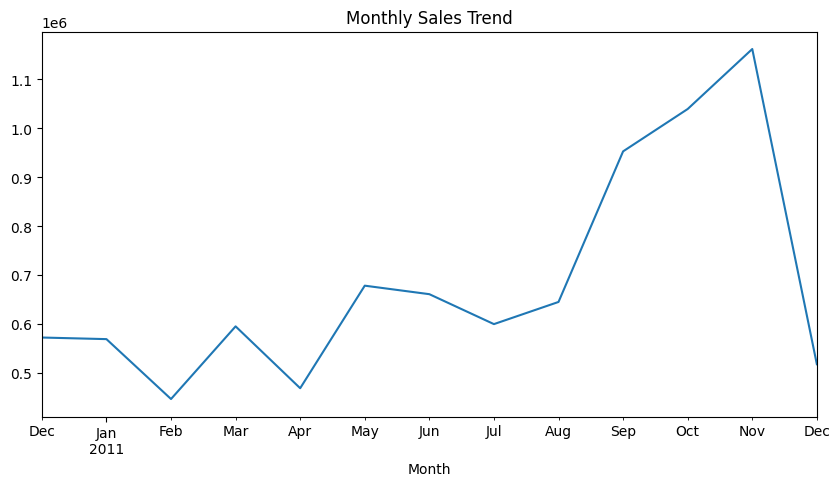

In [10]:
monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.show()

#Customer Analysis

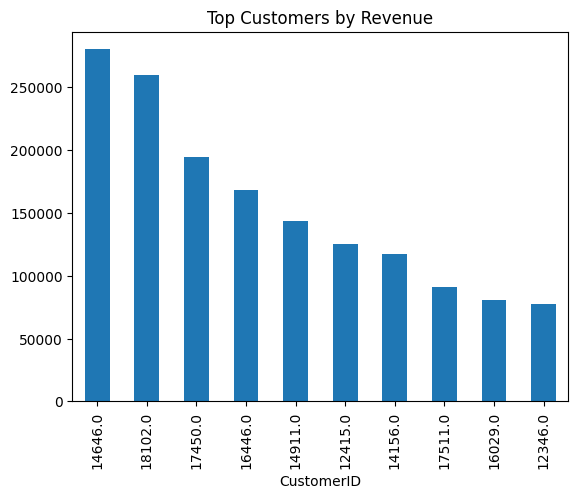

In [11]:
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)

top_customers.plot(kind='bar')
plt.title("Top Customers by Revenue")
plt.show()

#Product Analysis

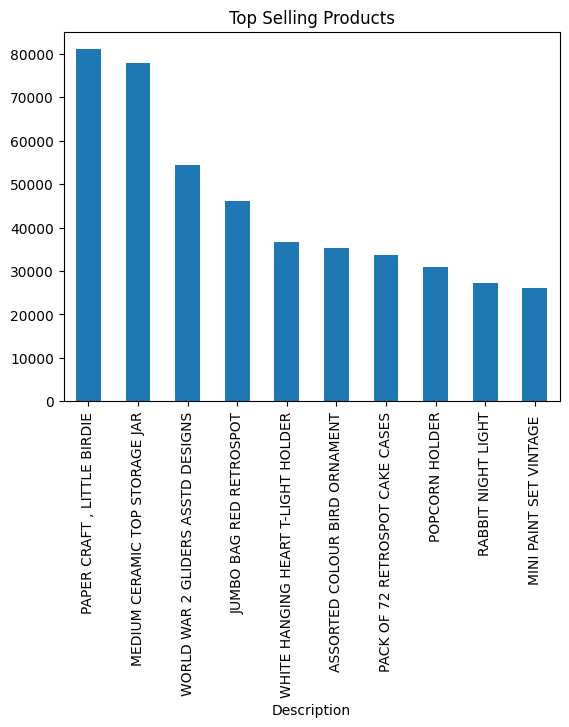

In [14]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')
plt.title("Top Selling Products")
plt.show()

#Country Analysis

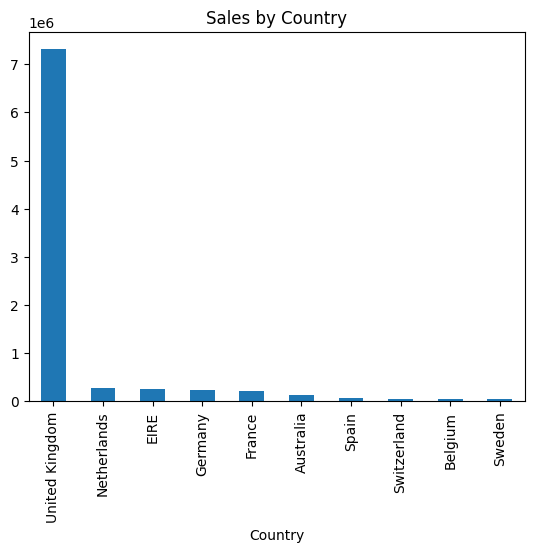

In [15]:
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)

country_sales.head(10).plot(kind='bar')
plt.title("Sales by Country")
plt.show()

#Heatmap Visualization

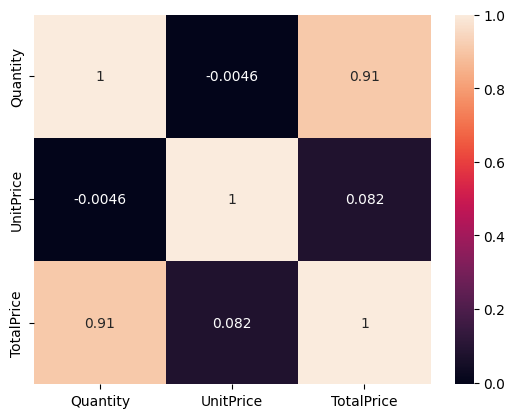

In [16]:
corr = df[['Quantity','UnitPrice','TotalPrice']].corr()

sns.heatmap(corr, annot=True)
plt.show()